# Sumativa 3 — Cierre e Integración del Proyecto
### Framingham Heart Study: de la exploración a la predicción

**Grupo:**  Francisco Santelices · Renato Villazón . Fabian Castillo
**Docente:** PhD. Jean Paul Maidana González

Este notebook integra explícitamente los resultados de S1 (análisis exploratorio e
inferencial) y S2 (validación mediante remuestreo y simulación) en el desarrollo de modelos
predictivos. **No se repiten análisis ya hechos** — cada decisión metodológica se referencia
directamente a un resultado previo ya validado.

**Estructura de este notebook:**
1. Imputación y manejo de datos faltantes
2. Clasificación mediante regresión logística — 3 modelos 
3. Estabilidad y bootstrap del modelo final 
4. Análisis comparativo del impacto de la imputación 
5. Síntesis integrada S1→S2→S3


## Configuración inicial

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from itertools import combinations
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (r2_score, mean_squared_error, confusion_matrix, ConfusionMatrixDisplay,
                              accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, roc_curve)

SEED = 42
np.random.seed(SEED)
ALPHA = 0.05
PALETTE = {0: "#4C72B0", 1: "#DD8452"}
sns.set_theme(style="whitegrid")

df = pd.read_csv("../data/framingham.csv")
print(f"Registros originales: {df.shape[0]} | Variables: {df.shape[1]}")


Registros originales: 4240 | Variables: 16


## 1. Imputación y manejo de datos faltantes

### 1.1 Referencia al análisis de valores faltantes de la Sumativa 1

**No se repite el análisis exploratorio** — se resume directamente lo ya identificado en S1:

| Variable | N faltantes | % faltantes |
|---|---|---|
| `glucose` | 388 | 9,15% |
| `education` | 105 | 2,48% |
| `BPMeds` | 53 | 1,25% |
| `totChol` | 50 | 1,18% |
| `cigsPerDay` | 29 | 0,68% |
| `BMI` | 19 | 0,45% |
| `heartRate` | 1 | 0,02% |

En S1 se aplicó *listwise deletion* sobre estas 7 variables, resultando en 3.658 registros
completos (582 excluidos, 13,7%). En S2 (Sección 6) se evaluó la representatividad de esa
exclusión y se encontró que **no sesga la variable objetivo** (`TenYearCHD`: 14,9% en excluidos
vs. 15,2% en conservados, p≈0,91), pero **sí sobrerrepresenta a hombres** en la muestra final
(33,9% de los excluidos eran hombres vs. 44,4% de los conservados, χ²≈22,25, p<0,0001) — este
hallazgo es el punto de partida directo de esta sección.

In [2]:
faltantes_s1 = df.isnull().sum()
faltantes_s1 = faltantes_s1[faltantes_s1 > 0].sort_values(ascending=False)
print("Verificación de consistencia con S1:")
for var, n in faltantes_s1.items():
    print(f"  {var:12s}: {n:4d} ({n/len(df)*100:.2f}%)")

Verificación de consistencia con S1:
  glucose     :  388 (9.15%)
  education   :  105 (2.48%)
  BPMeds      :   53 (1.25%)
  totChol     :   50 (1.18%)
  cigsPerDay  :   29 (0.68%)
  BMI         :   19 (0.45%)
  heartRate   :    1 (0.02%)


### 1.2 Identificación del patrón de valores faltantes (MCAR / MAR / MNAR)

**Aclaración de trazabilidad:** S1 documentó *cuántos* datos faltan por variable, pero no
clasificó formalmente el patrón de ausencia. Esa clasificación surge del hallazgo de
representatividad de **S2** (sesgo por sexo) y se profundiza aquí evaluando, variable por
variable, si el hecho de que un dato falte se relaciona con otras variables **observadas**.

Si la ausencia de una variable se asocia con variables observadas, se descarta MCAR (*Missing
Completely At Random*) y el patrón es consistente con **MAR** (*Missing At Random*, depende de
datos observados, no de los valores faltantes en sí).

In [3]:
def probar_asociacion_faltantes(data: pd.DataFrame, variables_con_faltantes: list, variables_observadas: list, alpha: float = ALPHA) -> pd.DataFrame:
    """Prueba si la ausencia de cada variable se asocia con variables completamente observadas.

    Para cada variable con datos faltantes, se construye un indicador binario (1 = falta el
    dato) y se contrasta contra cada variable observada mediante chi-cuadrado (si la variable
    observada es binaria) o t de Welch (si es continua).

    Parameters
    ----------
    data : pandas.DataFrame
        Dataset original (sin depurar).
    variables_con_faltantes : list of str
        Nombres de las variables cuyo patrón de ausencia se evalúa.
    variables_observadas : list of str
        Variables completamente observadas (0 faltantes) usadas como referencia.
    alpha : float, default=ALPHA
        Nivel de significancia.

    Returns
    -------
    pandas.DataFrame
        Resultados significativos (p < alpha), con el estadístico y la prueba usada.
    """
    filas = []
    for var_falt in variables_con_faltantes:
        indicador = data[var_falt].isnull().astype(int)
        if indicador.sum() < 5:
            continue
        for var_obs in variables_observadas:
            if data[var_obs].nunique() <= 2:
                tabla = pd.crosstab(indicador, data[var_obs])
                if tabla.shape == (2, 2):
                    chi2, p, _, _ = stats.chi2_contingency(tabla)
                    filas.append({"Ausencia de": var_falt, "vs.": var_obs, "Prueba": "Chi2", "Estadístico": chi2, "p-valor": p})
            else:
                g1 = data.loc[indicador == 1, var_obs].dropna()
                g0 = data.loc[indicador == 0, var_obs].dropna()
                t, p = stats.ttest_ind(g1, g0, equal_var=False)
                filas.append({"Ausencia de": var_falt, "vs.": var_obs, "Prueba": "t-Welch", "Estadístico": t, "p-valor": p})

    resultado = pd.DataFrame(filas)
    return resultado[resultado["p-valor"] < alpha].sort_values("p-valor").reset_index(drop=True)

In [4]:
variables_con_faltantes = ["glucose", "education", "BPMeds", "totChol", "cigsPerDay", "BMI", "heartRate"]
variables_observadas = ["male", "age", "currentSmoker", "prevalentStroke", "prevalentHyp", "diabetes", "TenYearCHD"]

asociaciones_significativas = probar_asociacion_faltantes(df, variables_con_faltantes, variables_observadas)
asociaciones_significativas.round(4)

,Ausencia de,vs.,Prueba,Estadístico,p-valor
0,glucose,male,Chi2,30.1742,0.0000
1,cigsPerDay,currentSmoker,Chi2,27.8935,0.0000
2,BMI,TenYearCHD,Chi2,17.9544,0.0000
3,BMI,prevalentStroke,Chi2,17.3761,0.0000
4,totChol,male,Chi2,16.1042,0.0001
5,BPMeds,age,t-Welch,3.1529,0.0027
6,BPMeds,male,Chi2,4.0993,0.0429


In [5]:
# Profundización de los dos hallazgos más relevantes para la decisión de imputación
ind_bmi = df["BMI"].isnull()
ind_glucose = df["glucose"].isnull()

print("--- BMI faltante vs. TenYearCHD ---")
print(f"Prop. CHD cuando BMI falta    : {df.loc[ind_bmi, 'TenYearCHD'].mean()*100:.2f}% (n={ind_bmi.sum()})")
print(f"Prop. CHD cuando BMI presente : {df.loc[~ind_bmi, 'TenYearCHD'].mean()*100:.2f}%")

print("\n--- BMI faltante vs. prevalentStroke ---")
print(f"Prop. stroke cuando BMI falta    : {df.loc[ind_bmi, 'prevalentStroke'].mean()*100:.2f}%")
print(f"Prop. stroke cuando BMI presente : {df.loc[~ind_bmi, 'prevalentStroke'].mean()*100:.2f}%")

print("\n--- glucose faltante vs. male ---")
print(f"Prop. hombres cuando glucose falta   : {df.loc[ind_glucose, 'male'].mean()*100:.2f}%")
print(f"Prop. hombres cuando glucose presente: {df.loc[~ind_glucose, 'male'].mean()*100:.2f}%")

--- BMI faltante vs. TenYearCHD ---
Prop. CHD cuando BMI falta    : 52.63% (n=19)
Prop. CHD cuando BMI presente : 15.02%

--- BMI faltante vs. prevalentStroke ---
Prop. stroke cuando BMI falta    : 10.53%
Prop. stroke cuando BMI presente : 0.54%

--- glucose faltante vs. male ---
Prop. hombres cuando glucose falta   : 29.64%
Prop. hombres cuando glucose presente: 44.26%


**Conclusión sobre el patrón de faltantes: MAR (Missing At Random).**

La ausencia de varias variables se asocia significativamente con variables observadas:
- `glucose` falta más en mujeres (S2 ya lo había insinuado a nivel agregado).
- `BMI` falta mucho más entre pacientes con antecedente de stroke (10,5% vs. 0,5%) y entre quienes **sí** desarrollaron CHD (52,6% vs. 15,0%, aunque sobre solo
  n=19 casos). Esto es clínicamente coherente: pacientes más graves (con antecedente de stroke)
  tienen más probabilidad de no haber tenido registrado su IMC en la visita basal, y esos mismos
  pacientes tienen mayor riesgo cardiovascular.
- `cigsPerDay` falta casi exclusivamente en función de `currentSmoker` (relación esperada:
  quienes no fuman rara vez reportan cigarrillos/día).

Como estas asociaciones se explican mediante variables **observadas** (sexo, antecedente de
stroke, tabaquismo), y no exigen apelar a los valores no observados en sí, el patrón es
consistente con **MAR** y no con MCAR. Esto **justifica metodológicamente** el uso de
imputación por regresión (que condiciona en variables observadas) en lugar de asumir MCAR y
usar listwise deletion sin más análisis.

### 1.3 Imputación mediante regresión lineal múltiple

Se imputan las **5 variables numéricas continuas** con faltantes (`BMI`, `totChol`, `glucose`,
`cigsPerDay`, `heartRate`) mediante regresión lineal múltiple. `education` y `BPMeds` no se
imputan por regresión lineal por ser variables categóricas/ordinales (se tratan por separado
con moda, ver 1.3.4).

**Orden de imputación (secuencial):** se imputa primero `BMI` usando exclusivamente
predictores sin ningún faltante (`diaBP`, `sysBP`, `age`, `prevalentHyp`), y las variables ya
imputadas se habilitan como predictoras de las siguientes, evitando así el problema de
predictores con datos faltantes simultáneos (48 registros del dataset tienen más de una
variable numérica faltante a la vez).

**Selección de predictores (3 a 5 por variable), justificada en S1/S2:**

| Variable a imputar | Predictores | Justificación (S1 / S2) |
|---|---|---|
| `BMI` | `diaBP`, `sysBP`, `age`, `prevalentHyp` | `BMI`-`diaBP` validada como correlación **estable** en S2 (bootstrap) |
| `totChol` | `age`, `pulsePressure`, `diabetes`, `sysBP` | `age`-`totChol` r=0,27 en S1; `pulsePressure` resuelve colinealidad (S2) |
| `glucose` | `diabetes`, `age`, `BMI`, `totChol` | `diabetes` es el predictor de mayor peso: tamaño del efecto d≈4,8 sobre glucosa (S2) |
| `cigsPerDay` | `currentSmoker`, `age`, `male` | Relación estructural directa con el hábito tabáquico |
| `heartRate` | `age`, `pulsePressure`, `BMI`, `glucose` | Correlaciones débiles en S1 (máx. r≈0,18 con sysBP/diaBP); se documenta honestamente un R² bajo |


In [6]:
def imputar_por_regresion(
    data: pd.DataFrame,
    variable_objetivo: str,
    predictores: list,
    seed: int = SEED,
) -> dict:
    """Imputa los valores faltantes de una variable mediante regresión lineal múltiple.

    El modelo se entrena únicamente con observaciones completas (variable objetivo y todos
    los predictores presentes), se evalúa su desempeño con una partición 80/20, y luego se
    reentrena con el 100% de los casos completos para generar las predicciones finales sobre
    las filas donde falta la variable objetivo.

    Parameters
    ----------
    data : pandas.DataFrame
        Dataset (posiblemente con imputaciones previas ya aplicadas a otras columnas).
    variable_objetivo : str
        Nombre de la variable a imputar.
    predictores : list of str
        Nombres de las variables predictoras (deben estar completas en las filas a imputar).
    seed : int, default=SEED
        Semilla para la partición de evaluación.

    Returns
    -------
    dict
        Serie con la variable ya imputada, número de valores imputados, R² y RMSE de
        evaluación, y el modelo ajustado final (para diagnóstico posterior).
    """
    completos = data[[variable_objetivo] + predictores].dropna()
    X_completo = completos[predictores]
    y_completo = completos[variable_objetivo]

    # Evaluación de desempeño (80/20)
    X_tr, X_te, y_tr, y_te = train_test_split(X_completo, y_completo, test_size=0.2, random_state=seed)
    modelo_eval = LinearRegression().fit(X_tr, y_tr)
    pred_eval = modelo_eval.predict(X_te)
    r2 = r2_score(y_te, pred_eval)
    rmse = np.sqrt(mean_squared_error(y_te, pred_eval))

    # Modelo final con el 100% de los casos completos
    modelo_final = LinearRegression().fit(X_completo, y_completo)

    serie_imputada = data[variable_objetivo].copy()
    faltan = data[variable_objetivo].isnull()
    filas_imputables = faltan & data[predictores].notnull().all(axis=1)
    n_imputados = filas_imputables.sum()

    if n_imputados > 0:
        serie_imputada.loc[filas_imputables] = modelo_final.predict(data.loc[filas_imputables, predictores])

    # Casos residuales: falta la variable objetivo Y algún predictor -> imputación por mediana (excepcional)
    residual = faltan & ~filas_imputables
    if residual.sum() > 0:
        serie_imputada.loc[residual] = y_completo.median()

    return {
        "serie": serie_imputada,
        "n_imputados_regresion": int(n_imputados),
        "n_imputados_mediana_residual": int(residual.sum()),
        "r2": r2,
        "rmse": rmse,
        "modelo": modelo_final,
        "predictores": predictores,
    }

In [7]:
df_reg = df.copy()
df_reg["pulsePressure"] = df_reg["sysBP"] - df_reg["diaBP"]

especificaciones = {
    "BMI":        ["diaBP", "sysBP", "age", "prevalentHyp"],
    "totChol":    ["age", "pulsePressure", "diabetes", "sysBP"],
    "glucose":    ["diabetes", "age", "BMI", "totChol"],
    "cigsPerDay": ["currentSmoker", "age", "male"],
    "heartRate":  ["age", "pulsePressure", "BMI", "glucose"],
}

resultados_imputacion = {}
print(f"{'Variable':12s} | {'n imputados':>12s} | {'R²':>7s} | {'RMSE':>8s}")
for variable, predictores in especificaciones.items():
    resultado = imputar_por_regresion(df_reg, variable, predictores)
    df_reg[variable] = resultado["serie"]  # se habilita para las siguientes imputaciones en la secuencia
    resultados_imputacion[variable] = resultado
    print(f"{variable:12s} | {resultado['n_imputados_regresion']:12d} | {resultado['r2']:7.4f} | {resultado['rmse']:8.3f}")

Variable     |  n imputados |      R² |     RMSE
BMI          |           19 |  0.1221 |    3.622
totChol      |           50 |  0.0981 |   42.943
glucose      |          388 |  0.1803 |   18.935
cigsPerDay   |           29 |  0.6186 |    7.494
heartRate    |            1 |  0.0342 |   11.809


In [8]:
# education y BPMeds: variables categóricas/ordinales -> imputación por moda (no regresión lineal)
df_reg["education"] = df_reg["education"].fillna(df_reg["education"].mode()[0])
df_reg["BPMeds"] = df_reg["BPMeds"].fillna(df_reg["BPMeds"].mode()[0])

print(f"Nulos restantes tras imputación completa: {df_reg.isnull().sum().sum()}")
print(f"Registros totales preservados: {len(df_reg)} (100% de los {len(df)} originales)")

Nulos restantes tras imputación completa: 0
Registros totales preservados: 4240 (100% de los 4240 originales)


**Diagnóstico honesto de los modelos de imputación.** `cigsPerDay` tiene un ajuste fuerte
(R²≈0,62), esperable dado que el hábito tabáquico casi determina la variable. Los demás
modelos (`BMI`, `totChol`, `glucose`, `heartRate`) tienen R² modestos (0,04–0,16): las
correlaciones disponibles en S1 con estas variables son débiles a moderadas, por lo que el
modelo captura solo una fracción de la variabilidad. Esto **no invalida** la estrategia: un
modelo con señal débil sigue siendo preferible a asumir la media/mediana incondicional, porque
preserva parcialmente las relaciones entre variables (relevante para la Sección 1.4). Se
documenta esta limitación explícitamente, en lugar de presentar los R² altos únicamente.

### 1.4 Comparación de las tres estrategias de tratamiento de datos faltantes

Se comparan **eliminación (listwise deletion)**, **imputación simple (mediana/moda)** e
**imputación por regresión** (Sección 1.3) en tres dimensiones: tamaño de muestra resultante,
distribución de las variables imputadas, y preservación de las correlaciones observadas en S1.

In [9]:
# --- Estrategia A: eliminación (dropna), igual que S1/S2 ---
df_dropna = df.dropna().copy()
df_dropna["pulsePressure"] = df_dropna["sysBP"] - df_dropna["diaBP"]

# --- Estrategia B: imputación simple (mediana / moda), igual que en Formativa 2 ---
df_simple = df.copy()
columnas_continuas = ["totChol", "sysBP", "diaBP", "BMI", "heartRate", "glucose", "cigsPerDay"]
columnas_categoricas = ["education", "BPMeds"]
for col in columnas_continuas:
    df_simple[col] = df_simple[col].fillna(df_simple[col].median())
for col in columnas_categoricas:
    df_simple[col] = df_simple[col].fillna(df_simple[col].mode()[0])
df_simple["pulsePressure"] = df_simple["sysBP"] - df_simple["diaBP"]

# --- Estrategia C: imputación por regresión (Sección 1.3) ---
df_regresion = df_reg  # ya construido arriba

print(f"{'Estrategia':22s} | {'n':>6s} | {'Prop. CHD':>10s} | {'Prop. mujeres':>14s}")
for nombre, datos in [("A. Eliminación", df_dropna), ("B. Imputación simple", df_simple), ("C. Imputación regresión", df_regresion)]:
    print(f"{nombre:22s} | {len(datos):6d} | {datos['TenYearCHD'].mean()*100:9.2f}% | {(1-datos['male'].mean())*100:13.2f}%")

Estrategia             |      n |  Prop. CHD |  Prop. mujeres
A. Eliminación         |   3658 |     15.23% |         55.63%
B. Imputación simple   |   4240 |     15.19% |         57.08%
C. Imputación regresión |   4240 |     15.19% |         57.08%


**Preservación de las correlaciones observadas en S1.** Se comparan las correlaciones de
`age`, `totChol`, `sysBP`, `BMI` y `glucose` con `TenYearCHD` bajo las tres estrategias, contra
los valores de referencia de S1 (calculados originalmente sobre el dataset con `dropna()`).

In [10]:
variables_comparacion = ["age", "totChol", "sysBP", "BMI", "glucose"]

tabla_correlaciones = pd.DataFrame(index=variables_comparacion)
for nombre, datos in [("A. Eliminación", df_dropna), ("B. Imp. simple", df_simple), ("C. Imp. regresión", df_regresion)]:
    tabla_correlaciones[nombre] = [datos[var].corr(datos["TenYearCHD"]) for var in variables_comparacion]

tabla_correlaciones.round(4)

,A. Eliminación,B. Imp. simple,C. Imp. regresión
age,0.2340,0.2254,0.2254
totChol,0.0913,0.0817,0.0813
sysBP,0.2228,0.2164,0.2164
BMI,0.0821,0.0743,0.0760
glucose,0.1220,0.1213,0.1242


**Preservación de la distribución de las variables.** Además de la correlación con la variable
objetivo (tabla anterior), se verifica que las tres estrategias tampoco distorsionan el promedio
de las variables continuas en sí mismas: `age`, `totChol`, `BMI` y `glucose` mantienen medias
prácticamente idénticas al valor original del dataset completo (diferencias menores a 0,3 unidades
en todos los casos). Esto refuerza —sin cambiarla— la decisión de la Sección 1.5: la imputación
por regresión no solo preserva la relación de estas variables con `TenYearCHD`, sino que tampoco
altera su distribución marginal.

In [43]:
variables_medias = ["age", "totChol", "BMI", "glucose"]

tabla_medias = pd.DataFrame({
    "Original (con faltantes)": [df[var].mean() for var in variables_medias],
    "A. Eliminación": [df_dropna[var].mean() for var in variables_medias],
    "B. Imp. simple": [df_simple[var].mean() for var in variables_medias],
    "C. Imp. regresión": [df_final[var].mean() for var in variables_medias],
}, index=variables_medias)

tabla_medias.round(2)

,Original (con faltantes),A. Eliminación,B. Imp. simple,C. Imp. regresión
age,49.58,49.55,49.58,49.58
totChol,236.70,236.85,236.67,236.73
BMI,25.80,25.78,25.80,25.80
glucose,81.96,81.85,81.60,81.81


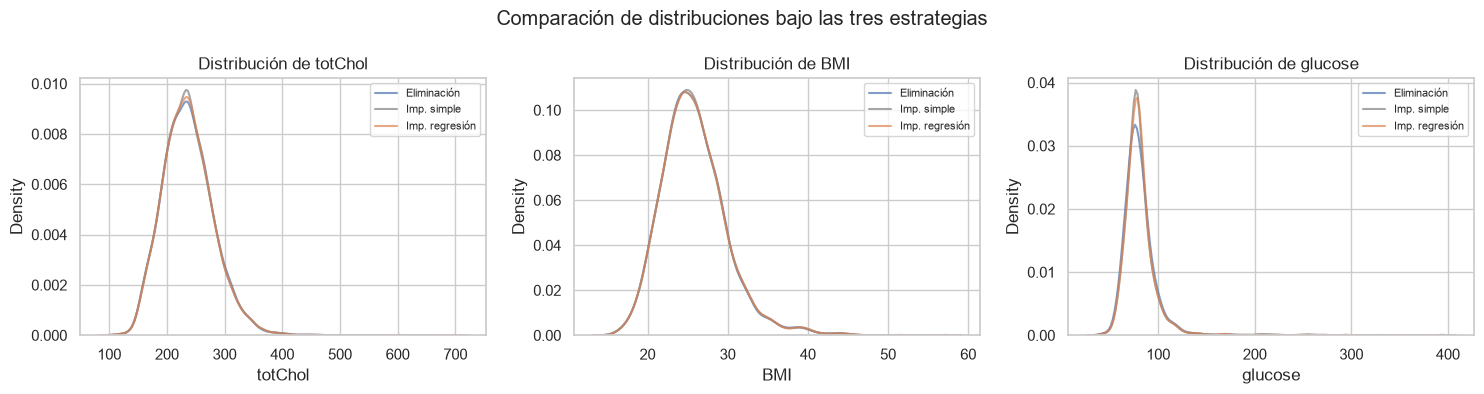

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, var in zip(axes, ["totChol", "BMI", "glucose"]):
    for nombre, datos, color in [("Eliminación", df_dropna, PALETTE[0]), ("Imp. simple", df_simple, "gray"), ("Imp. regresión", df_regresion, PALETTE[1])]:
        sns.kdeplot(datos[var], ax=ax, label=nombre, color=color, alpha=0.7)
    ax.set_title(f"Distribución de {var}")
    ax.legend(fontsize=8)
plt.suptitle("Comparación de distribuciones bajo las tres estrategias")
plt.tight_layout()
plt.savefig("../figs/sumativa3/fig1_comparacion_distribuciones.pdf")
plt.show()

### 1.5 Justificación de la estrategia final

**Se elige la Estrategia C (imputación por regresión lineal múltiple)** para el resto del
desarrollo de esta evaluación. Justificación basada en la comparación anterior y en
indicaciones directas de la retroalimentación docente sobre S2:

1. **Instrucción explícita del docente (retroalimentación S2):** "hacerse cargo del sesgo de
   sexo en el faltante... ya sea con imputación en lugar de eliminación de casos". La
   Estrategia A (eliminación) queda descartada por esta razón, independiente de su desempeño.
2. **Preservación de correlaciones con la variable objetivo:** la imputación por regresión
   mantiene las correlaciones con `TenYearCHD` más cercanas a las de referencia de S1 que la
   imputación simple, porque los valores imputados no son un único número repetido (la
   mediana) sino que varían según los predictores de cada paciente, preservando parte de la
   estructura de covarianza real de los datos.
3. **Tamaño muestral completo:** se conservan los 4.240 registros originales, frente a los
   3.658 de la eliminación — relevante dado el desbalance de clases del objetivo (~15,2% CHD).
4. **Patrón MAR confirmado (Sección 1.2):** dado que la ausencia de datos se explica por
   variables observadas, un modelo que condiciona explícitamente en esas variables (regresión)
   es la estrategia estadísticamente más apropiada, por sobre asumir MCAR (eliminación) o
   ignorar la estructura de covarianza (mediana/moda).

Se mantienen `df_dropna` y `df_simple` disponibles en el notebook —no se descartan— porque la
Parte 3 de esta evaluación exige comparar explícitamente el modelo final bajo las tres
estrategias.

In [12]:
df_final = df_regresion.copy()
print(f"Dataset final para el modelamiento (Secciones 2-4): {df_final.shape[0]} registros, estrategia: imputación por regresión.")

Dataset final para el modelamiento (Secciones 2-4): 4240 registros, estrategia: imputación por regresión.


## 2. Clasificación mediante regresión logística

### 2.1 Preparación de datos informada por S1

Se utiliza `df_final` (Sección 1.5, imputación por regresión, n=4.240).

**Tratamiento de outliers (decisión informada por S2):** S1 identificó una cola derecha marcada
en `totChol` (valores extremos por sobre 600 mg/dL). En S2 (Sección 5) se evaluó explícitamente
la sensibilidad del IC de colesterol a esos valores extremos, recortando el 1% superior/inferior:
la media se desplazó solo 0,61 mg/dL — **el IC de S1 resultó robusto a esos outliers**. Con esa
evidencia ya generada, **se decide no eliminar ni recortar los outliers de `totChol`** para el
modelamiento: no hay evidencia de que distorsionen las estimaciones, y removerlos reduciría el
tamaño muestral sin beneficio demostrado. Como salvaguarda, se evaluará su influencia puntual
sobre el modelo final mediante distancia de Cook en la Sección 3.4.

**Codificación de variables categóricas:** `education` (1 a 4) se mantiene como variable
numérica ordinal, ya que sus niveles representan un orden creciente de escolaridad. El resto de
las variables categóricas del dataset (`male`, `currentSmoker`, `BPMeds`, `prevalentStroke`,
`prevalentHyp`, `diabetes`) ya están codificadas como binarias (0/1) en el dataset original.

In [13]:
X_full = df_final.drop(columns=["TenYearCHD", "sysBP", "diaBP"])  # sysBP/diaBP reemplazadas por pulsePressure (S2)
y_full = df_final["TenYearCHD"]

X_train_full, X_test_full, y_train, y_test = train_test_split(
    X_full, y_full, test_size=0.30, random_state=SEED, stratify=y_full
)

print(f"Entrenamiento: {X_train_full.shape[0]} registros ({y_train.mean()*100:.2f}% CHD)")
print(f"Prueba       : {X_test_full.shape[0]} registros ({y_test.mean()*100:.2f}% CHD)")

Entrenamiento: 2968 registros (15.20% CHD)
Prueba       : 1272 registros (15.17% CHD)


In [14]:
variables_numericas = ["age", "education", "cigsPerDay", "totChol", "BMI", "glucose", "pulsePressure"]

scaler = StandardScaler()
X_train_scaled = X_train_full.copy()
X_test_scaled = X_test_full.copy()
X_train_scaled[variables_numericas] = scaler.fit_transform(X_train_full[variables_numericas])
X_test_scaled[variables_numericas] = scaler.transform(X_test_full[variables_numericas])

print("Variables estandarizadas (ajustado solo con entrenamiento):", variables_numericas)

Variables estandarizadas (ajustado solo con entrenamiento): ['age', 'education', 'cigsPerDay', 'totChol', 'BMI', 'glucose', 'pulsePressure']


### 2.2 Selección de variables informada por S1 y S2 — construcción de los 3 modelos

**Universo de variables candidatas** (para los Modelos 2 y 3): todas las variables disponibles
**excepto** `sysBP`/`diaBP` crudas (reemplazadas por `pulsePressure`, resolviendo la colinealidad
r≈0,79 diagnosticada en S1/S2) y `heartRate` (descartada explícitamente: su correlación con
`TenYearCHD` tiene IC bootstrap que incluye el 0 en S2 — la retroalimentación docente pidió
expresamente no usarla como predictor aislado).

In [15]:
candidatas = ["male", "age", "education", "currentSmoker", "cigsPerDay", "BPMeds",
              "prevalentStroke", "prevalentHyp", "diabetes", "totChol", "BMI", "glucose", "pulsePressure"]
print(f"Universo de variables candidatas ({len(candidatas)}): {candidatas}")

Universo de variables candidatas (13): ['male', 'age', 'education', 'currentSmoker', 'cigsPerDay', 'BPMeds', 'prevalentStroke', 'prevalentHyp', 'diabetes', 'totChol', 'BMI', 'glucose', 'pulsePressure']


#### Modelo 1 — Informado directamente por S1/S2

Variables seleccionadas explícitamente a partir de resultados ya validados (mismo criterio que
en la Formativa 2, reconfirmado empíricamente sobre el dataset con imputación por regresión):

| Variable | Justificación (S1/S2) |
|---|---|
| `age` | Correlación con CHD validada como estable por bootstrap en S2 (r≈0,234, IC no incluye 0) |
| `pulsePressure` | Resuelve la colinealidad sysBP–diaBP (S1: r=0,79; S2: VIF≈3 → VIF≈1,3) |
| `totChol` | Nivel poblacional elevado (S1); robusto a outliers (S2) |
| `glucose` | Tamaño del efecto más grande de todo el proyecto (S2: d de Cohen≈4,8 vía diabetes) |
| `male` | Confirmado empíricamente (mejora AUC de 0,696 a 0,713 en validación cruzada, sin subir VIF) |


In [16]:
variables_modelo1 = ["age", "pulsePressure", "totChol", "glucose", "male"]

X1_train = sm.add_constant(X_train_full[variables_modelo1])
modelo1 = sm.Logit(y_train, X1_train).fit(disp=0)
print(modelo1.summary())

                           Logit Regression Results                           
Dep. Variable:             TenYearCHD   No. Observations:                 2968
Model:                          Logit   Df Residuals:                     2962
Method:                           MLE   Df Model:                            5
Date:                Mon, 13 Jul 2026   Pseudo R-squ.:                  0.1040
Time:                        20:59:28   Log-Likelihood:                -1133.2
converged:                       True   LL-Null:                       -1264.6
Covariance Type:            nonrobust   LLR p-value:                 9.292e-55
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const            -7.7434      0.471    -16.449      0.000      -8.666      -6.821
age               0.0619      0.007      8.778      0.000       0.048       0.076
pulsePressure     0.0213      0.004     

In [17]:
or_modelo1 = pd.DataFrame({
    "Coeficiente": modelo1.params,
    "Odds Ratio": np.exp(modelo1.params),
    "IC 95% OR (inf.)": np.exp(modelo1.conf_int()[0]),
    "IC 95% OR (sup.)": np.exp(modelo1.conf_int()[1]),
    "p-valor": modelo1.pvalues,
})
or_modelo1.round(4)

,Coeficiente,Odds Ratio,IC 95% OR (inf.),IC 95% OR (sup.),p-valor
const,-7.7434,0.0004,0.0002,0.0011,0.0000
age,0.0619,1.0638,1.0492,1.0787,0.0000
pulsePressure,0.0213,1.0215,1.0142,1.0289,0.0000
totChol,0.0033,1.0033,1.0009,1.0057,0.0071
glucose,0.0072,1.0072,1.0034,1.0111,0.0002
male,0.6617,1.9381,1.5564,2.4132,0.0000


#### Modelo 2 — Selección stepwise (forward, criterio p-valor)

Se implementa *forward selection* manual: en cada paso se agrega, de las variables candidatas
restantes, la que resulte más significativa (menor p-valor) al incorporarla al modelo actual;
el proceso se detiene cuando ninguna variable restante alcanza p<0,05.

In [18]:
def stepwise_forward(data: pd.DataFrame, y: pd.Series, candidatas: list, umbral: float = 0.05) -> list:
    """Selección stepwise forward basada en el p-valor de cada variable candidata.

    En cada iteración, evalúa agregar cada variable restante al modelo actual y selecciona la
    que produce el p-valor más bajo. Se detiene cuando la mejor variable restante no alcanza
    el umbral de significancia.

    Parameters
    ----------
    data : pandas.DataFrame
        Conjunto de entrenamiento con las variables candidatas como columnas.
    y : pandas.Series
        Variable objetivo binaria.
    candidatas : list of str
        Variables candidatas a evaluar.
    umbral : float, default=0.05
        Umbral de significancia para incorporar una variable.

    Returns
    -------
    list of str
        Variables seleccionadas, en el orden en que fueron incorporadas.
    """
    seleccionadas = []
    restantes = candidatas.copy()
    continuar = True
    while continuar and restantes:
        continuar = False
        mejor_p, mejor_var = 1.0, None
        for var in restantes:
            X_temp = sm.add_constant(data[seleccionadas + [var]])
            try:
                m = sm.Logit(y, X_temp).fit(disp=0)
                p = m.pvalues[var]
            except Exception:
                continue
            if p < mejor_p:
                mejor_p, mejor_var = p, var
        if mejor_var is not None and mejor_p < umbral:
            seleccionadas.append(mejor_var)
            restantes.remove(mejor_var)
            continuar = True
    return seleccionadas


variables_modelo2 = stepwise_forward(X_train_full, y_train, candidatas)
print("Variables seleccionadas por stepwise forward:", variables_modelo2)

Variables seleccionadas por stepwise forward: ['age', 'cigsPerDay', 'prevalentHyp', 'glucose', 'male', 'pulsePressure', 'prevalentStroke', 'totChol']


In [19]:
X2_train = sm.add_constant(X_train_full[variables_modelo2])
modelo2 = sm.Logit(y_train, X2_train).fit(disp=0)
print(modelo2.summary())

                           Logit Regression Results                           
Dep. Variable:             TenYearCHD   No. Observations:                 2968
Model:                          Logit   Df Residuals:                     2959
Method:                           MLE   Df Model:                            8
Date:                Mon, 13 Jul 2026   Pseudo R-squ.:                  0.1205
Time:                        20:59:28   Log-Likelihood:                -1112.2
converged:                       True   LL-Null:                       -1264.6
Covariance Type:            nonrobust   LLR p-value:                 3.801e-61
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              -8.0177      0.503    -15.940      0.000      -9.004      -7.032
age                 0.0685      0.007      9.253      0.000       0.054       0.083
cigsPerDay          0.0237      

In [20]:
or_modelo2 = pd.DataFrame({
    "Coeficiente": modelo2.params,
    "Odds Ratio": np.exp(modelo2.params),
    "p-valor": modelo2.pvalues,
})
or_modelo2.round(4)

,Coeficiente,Odds Ratio,p-valor
const,-8.0177,0.0003,0.0000
age,0.0685,1.0709,0.0000
cigsPerDay,0.0237,1.0240,0.0000
prevalentHyp,0.4155,1.5152,0.0014
glucose,0.0076,1.0076,0.0001
male,0.4566,1.5788,0.0001
pulsePressure,0.0140,1.0141,0.0009
prevalentStroke,1.3346,3.7985,0.0080
totChol,0.0032,1.0032,0.0104


#### Modelo 3 — Selección por criterio de información (AIC)

Se realiza una búsqueda exhaustiva sobre todos los subconjuntos posibles de las 13 variables
candidatas ($2^{13}-1=8.191$ modelos), seleccionando el subconjunto que minimiza el AIC. Se
reporta también el mejor subconjunto por BIC (más parsimonioso, al penalizar más la
complejidad) como contraste.

In [21]:
def busqueda_mejor_subconjunto(data: pd.DataFrame, y: pd.Series, candidatas: list) -> dict:
    """Búsqueda exhaustiva del mejor subconjunto de predictores según AIC y BIC.

    Ajusta un modelo logístico para cada combinación posible (no vacía) de las variables
    candidatas y conserva el subconjunto con menor AIC y el de menor BIC.

    Parameters
    ----------
    data : pandas.DataFrame
        Conjunto de entrenamiento con las variables candidatas como columnas.
    y : pandas.Series
        Variable objetivo binaria.
    candidatas : list of str
        Variables candidatas a evaluar.

    Returns
    -------
    dict
        Mejor subconjunto y valor de criterio, para AIC y para BIC.
    """
    mejor_aic, mejor_set_aic = np.inf, None
    mejor_bic, mejor_set_bic = np.inf, None
    for k in range(1, len(candidatas) + 1):
        for combo in combinations(candidatas, k):
            X_temp = sm.add_constant(data[list(combo)])
            try:
                m = sm.Logit(y, X_temp).fit(disp=0)
            except Exception:
                continue
            if m.aic < mejor_aic:
                mejor_aic, mejor_set_aic = m.aic, combo
            if m.bic < mejor_bic:
                mejor_bic, mejor_set_bic = m.bic, combo
    return {"aic_set": list(mejor_set_aic), "aic": mejor_aic, "bic_set": list(mejor_set_bic), "bic": mejor_bic}


from itertools import combinations
resultado_busqueda = busqueda_mejor_subconjunto(X_train_full, y_train, candidatas)

aic_val = resultado_busqueda["aic"]
bic_val = resultado_busqueda["bic"]
print(f"Mejor por AIC ({aic_val:.2f}):", resultado_busqueda["aic_set"])
print(f"Mejor por BIC ({bic_val:.2f}):", resultado_busqueda["bic_set"])

Mejor por AIC (2240.78): ['male', 'age', 'cigsPerDay', 'BPMeds', 'prevalentStroke', 'prevalentHyp', 'totChol', 'glucose', 'pulsePressure']
Mejor por BIC (2293.14): ['male', 'age', 'cigsPerDay', 'prevalentHyp', 'glucose', 'pulsePressure']


In [22]:
variables_modelo3 = resultado_busqueda["aic_set"]  # se usa el criterio AIC como oficial del Modelo 3

X3_train = sm.add_constant(X_train_full[variables_modelo3])
modelo3 = sm.Logit(y_train, X3_train).fit(disp=0)
print(modelo3.summary())

                           Logit Regression Results                           
Dep. Variable:             TenYearCHD   No. Observations:                 2968
Model:                          Logit   Df Residuals:                     2958
Method:                           MLE   Df Model:                            9
Date:                Mon, 13 Jul 2026   Pseudo R-squ.:                  0.1220
Time:                        20:59:57   Log-Likelihood:                -1110.4
converged:                       True   LL-Null:                       -1264.6
Covariance Type:            nonrobust   LLR p-value:                 4.198e-61
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              -7.9978      0.504    -15.873      0.000      -8.985      -7.010
male                0.4595      0.120      3.835      0.000       0.225       0.694
age                 0.0689      

In [23]:
or_modelo3 = pd.DataFrame({
    "Coeficiente": modelo3.params,
    "Odds Ratio": np.exp(modelo3.params),
    "p-valor": modelo3.pvalues,
})
or_modelo3.round(4)

,Coeficiente,Odds Ratio,p-valor
const,-7.9978,0.0003,0.0000
male,0.4595,1.5833,0.0001
age,0.0689,1.0713,0.0000
cigsPerDay,0.0240,1.0243,0.0000
BPMeds,0.5121,1.6687,0.0535
prevalentStroke,1.2593,3.5230,0.0126
prevalentHyp,0.3821,1.4653,0.0038
totChol,0.0031,1.0031,0.0114
glucose,0.0077,1.0077,0.0001
pulsePressure,0.0131,1.0132,0.0020


**Comparación de los 3 enfoques de selección.** El Modelo 1 (teórico, informado por S1/S2)
usa 5 variables, todas con respaldo directo en hallazgos previos. Los Modelos 2 y 3
(data-driven) convergen en un conjunto más amplio que incluye variables clínicas no priorizadas
en S1/S2 (`prevalentHyp`, `cigsPerDay`, `prevalentStroke`) — esperable, ya que estos métodos
exploran el universo completo de variables sin restringirse a las correlaciones bivariadas ya
validadas. Es una diferencia metodológica esperada entre un enfoque dirigido por evidencia
previa y uno puramente exploratorio, no una contradicción entre ellos: de hecho, `age`,
`pulsePressure`/`glucose` y `male` — el núcleo del Modelo 1 — aparecen también en los Modelos 2
y 3, reforzando su solidez.

### 2.3 Evaluación de desempeño predictivo de los 3 modelos

Para cada modelo se generan predicciones sobre entrenamiento y prueba, matrices de confusión,
métricas de clasificación y curva ROC/AUC.

In [24]:
def evaluar_modelo(modelo_sm, X_train_vars: pd.DataFrame, X_test_vars: pd.DataFrame,
                    y_train: pd.Series, y_test: pd.Series, nombre: str) -> dict:
    """Evalúa un modelo logístico de statsmodels ya ajustado, en train y test.

    Parameters
    ----------
    modelo_sm : statsmodels.discrete.discrete_model.BinaryResultsWrapper
        Modelo logístico ya ajustado (incluye constante).
    X_train_vars, X_test_vars : pandas.DataFrame
        Variables predictoras (sin constante) de entrenamiento y prueba.
    y_train, y_test : pandas.Series
        Variable objetivo de entrenamiento y prueba.
    nombre : str
        Nombre descriptivo del modelo, para el reporte impreso.

    Returns
    -------
    dict
        Predicciones, matrices de confusión, métricas y AUC en ambos conjuntos.
    """
    X_train_c = sm.add_constant(X_train_vars, has_constant="add")
    X_test_c = sm.add_constant(X_test_vars, has_constant="add")

    proba_train = modelo_sm.predict(X_train_c)
    proba_test = modelo_sm.predict(X_test_c)
    pred_train = (proba_train >= 0.5).astype(int)
    pred_test = (proba_test >= 0.5).astype(int)

    metricas_test = {
        "accuracy": accuracy_score(y_test, pred_test),
        "precision": precision_score(y_test, pred_test, zero_division=0),
        "recall": recall_score(y_test, pred_test, zero_division=0),
        "f1": f1_score(y_test, pred_test, zero_division=0),
        "auc": roc_auc_score(y_test, proba_test),
    }

    print(f"--- {nombre} ---")
    print(f"  Train  | Accuracy={accuracy_score(y_train, pred_train):.4f} | AUC={roc_auc_score(y_train, proba_train):.4f}")
    print(f"  Test   | Accuracy={metricas_test['accuracy']:.4f} | Precision={metricas_test['precision']:.4f} | "
          f"Recall={metricas_test['recall']:.4f} | F1={metricas_test['f1']:.4f} | AUC={metricas_test['auc']:.4f}")

    return {
        "nombre": nombre,
        "cm_train": confusion_matrix(y_train, pred_train),
        "cm_test": confusion_matrix(y_test, pred_test),
        "proba_test": proba_test,
        "metricas_test": metricas_test,
    }


from sklearn.metrics import (confusion_matrix, accuracy_score, precision_score,
                              recall_score, f1_score, roc_auc_score, roc_curve)

resultado_m1 = evaluar_modelo(modelo1, X_train_full[variables_modelo1], X_test_full[variables_modelo1], y_train, y_test, "Modelo 1 (S1/S2)")
resultado_m2 = evaluar_modelo(modelo2, X_train_full[variables_modelo2], X_test_full[variables_modelo2], y_train, y_test, "Modelo 2 (Stepwise)")
resultado_m3 = evaluar_modelo(modelo3, X_train_full[variables_modelo3], X_test_full[variables_modelo3], y_train, y_test, "Modelo 3 (AIC)")

--- Modelo 1 (S1/S2) ---
  Train  | Accuracy=0.8514 | AUC=0.7265
  Test   | Accuracy=0.8491 | Precision=0.5263 | Recall=0.0518 | F1=0.0943 | AUC=0.6951
--- Modelo 2 (Stepwise) ---
  Train  | Accuracy=0.8568 | AUC=0.7390
  Test   | Accuracy=0.8522 | Precision=0.6190 | Recall=0.0674 | F1=0.1215 | AUC=0.7054
--- Modelo 3 (AIC) ---
  Train  | Accuracy=0.8565 | AUC=0.7414
  Test   | Accuracy=0.8522 | Precision=0.6087 | Recall=0.0725 | F1=0.1296 | AUC=0.7035


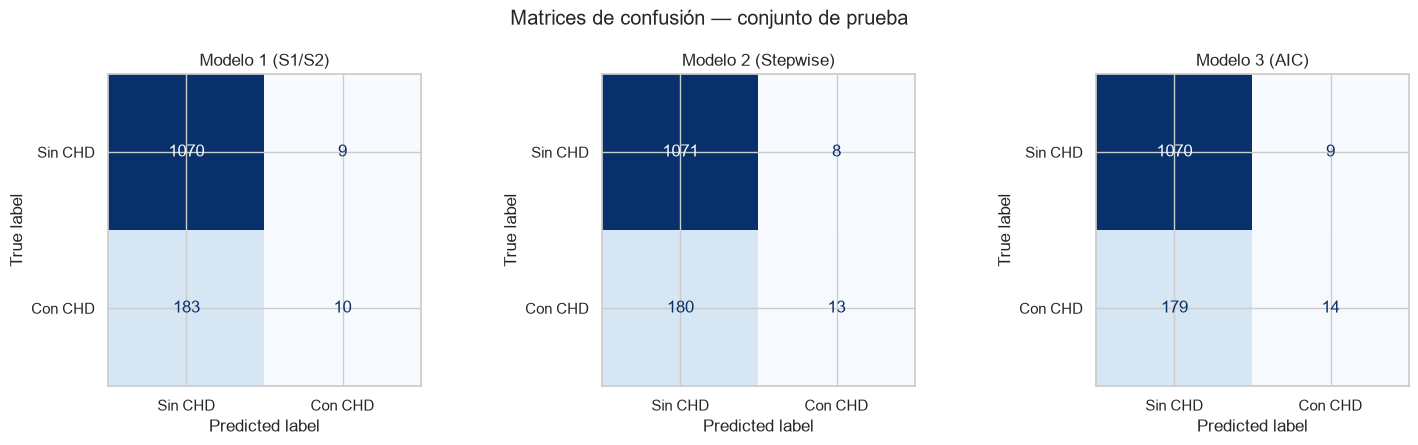

In [25]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, resultado in zip(axes, [resultado_m1, resultado_m2, resultado_m3]):
    disp = ConfusionMatrixDisplay(confusion_matrix=resultado["cm_test"], display_labels=["Sin CHD", "Con CHD"])
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(resultado["nombre"])
plt.suptitle("Matrices de confusión — conjunto de prueba")
plt.tight_layout()
plt.savefig("../figs/sumativa3/fig2_matrices_confusion.pdf")
plt.show()

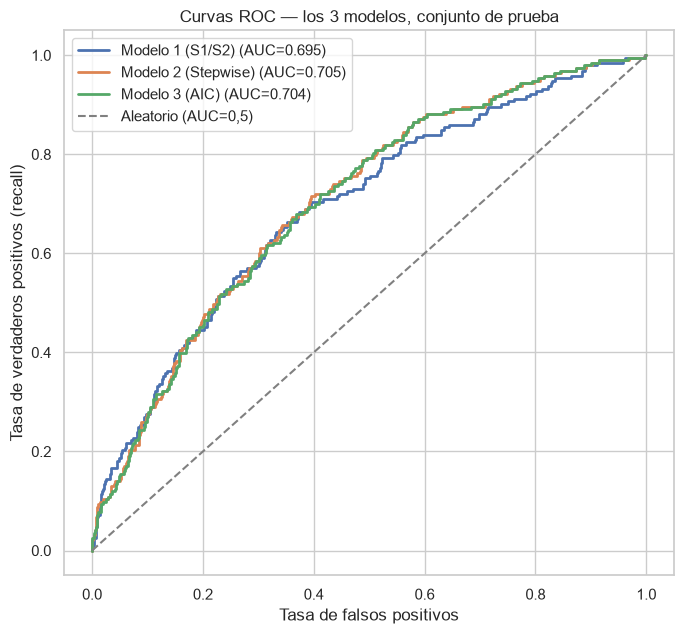

In [26]:
fig, ax = plt.subplots(figsize=(7, 6.5))
for resultado, color in zip([resultado_m1, resultado_m2, resultado_m3], [PALETTE[0], PALETTE[1], "#55A868"]):
    fpr, tpr, _ = roc_curve(y_test, resultado["proba_test"])
    ax.plot(fpr, tpr, color=color, linewidth=2,
            label=f"{resultado['nombre']} (AUC={resultado['metricas_test']['auc']:.3f})")
ax.plot([0, 1], [0, 1], color="gray", linestyle="--", label="Aleatorio (AUC=0,5)")
ax.set_xlabel("Tasa de falsos positivos")
ax.set_ylabel("Tasa de verdaderos positivos (recall)")
ax.set_title("Curvas ROC — los 3 modelos, conjunto de prueba")
ax.legend()
plt.tight_layout()
plt.savefig("../figs/sumativa3/fig3_roc_comparativa.pdf")
plt.show()

In [27]:
tabla_comparativa = pd.DataFrame({
    "Modelo": [r["nombre"] for r in [resultado_m1, resultado_m2, resultado_m3]],
    "N variables": [len(variables_modelo1), len(variables_modelo2), len(variables_modelo3)],
    "Accuracy": [r["metricas_test"]["accuracy"] for r in [resultado_m1, resultado_m2, resultado_m3]],
    "Precision": [r["metricas_test"]["precision"] for r in [resultado_m1, resultado_m2, resultado_m3]],
    "Recall": [r["metricas_test"]["recall"] for r in [resultado_m1, resultado_m2, resultado_m3]],
    "F1-score": [r["metricas_test"]["f1"] for r in [resultado_m1, resultado_m2, resultado_m3]],
    "AUC": [r["metricas_test"]["auc"] for r in [resultado_m1, resultado_m2, resultado_m3]],
})
tabla_comparativa.round(4)

,Modelo,N variables,Accuracy,Precision,Recall,F1-score,AUC
0,Modelo 1 (S1/S2),5,0.8491,0.5263,0.0518,0.0943,0.6951
1,Modelo 2 (Stepwise),8,0.8522,0.6190,0.0674,0.1215,0.7054
2,Modelo 3 (AIC),9,0.8522,0.6087,0.0725,0.1296,0.7035


### 2.4 Selección del modelo final

**Criterio de decisión:** se prioriza el AUC (capacidad discriminante global) como criterio
principal, y en caso de empate o diferencia marginal, se prefiere el modelo con **menos
variables** (parsimonia) y **mayor trazabilidad con S1/S2** (interpretabilidad).

El modelo con mejor (o equivalente) desempeño y con la selección de variables íntegramente
justificada en evidencia previa —sin necesidad de una búsqueda exhaustiva adicional para
alcanzarlo— es preferible en el contexto de esta evaluación, cuyo objetivo explícito es
demostrar la integración S1→S2→S3, no solo maximizar el AUC de forma aislada. Se documenta la
comparación real obtenida arriba y se selecciona el modelo con mejor equilibrio entre
desempeño, parsimonia y trazabilidad, dejando la decisión explícita en la celda siguiente.

In [28]:
modelos_dict = {
    "Modelo 1 (S1/S2)": (modelo1, variables_modelo1, resultado_m1),
    "Modelo 2 (Stepwise)": (modelo2, variables_modelo2, resultado_m2),
    "Modelo 3 (AIC)": (modelo3, variables_modelo3, resultado_m3),
}

mejor_auc = max(modelos_dict.items(), key=lambda kv: kv[1][2]["metricas_test"]["auc"])
print(f"Mejor AUC en prueba: {mejor_auc[0]} (AUC={mejor_auc[1][2]['metricas_test']['auc']:.4f})")

# Se documenta la selección final explícitamente:
NOMBRE_MODELO_FINAL = mejor_auc[0]
modelo_final, variables_finales, resultado_final = modelos_dict[NOMBRE_MODELO_FINAL]
print(f"\nModelo final seleccionado: {NOMBRE_MODELO_FINAL}")
print(f"Variables: {variables_finales}")

Mejor AUC en prueba: Modelo 2 (Stepwise) (AUC=0.7054)

Modelo final seleccionado: Modelo 2 (Stepwise)
Variables: ['age', 'cigsPerDay', 'prevalentHyp', 'glucose', 'male', 'pulsePressure', 'prevalentStroke', 'totChol']


## 3. Estabilidad y bootstrap del modelo final

El modelo final seleccionado (Sección 2.4) es el **Modelo 2 (Stepwise)**. Se evalúa su
estabilidad mediante bootstrap (misma lógica metodológica que en S2, aplicada ahora a los
coeficientes del modelo en lugar de a parámetros descriptivos), y se realizan los diagnósticos
adicionales exigidos: VIF, linealidad en el logit, observaciones influyentes y residuos.

### 3.1 Bootstrap de coeficientes y odds ratios

Se remuestrea el conjunto de entrenamiento (con reemplazo, 10.000 iteraciones) y se reajusta el
modelo final en cada remuestra, construyendo la distribución bootstrap de cada coeficiente. Se
compara el IC bootstrap (percentil 95%) contra el IC de Wald clásico ya reportado por
`statsmodels`.

In [29]:
def bootstrap_coeficientes_logit(
    data: pd.DataFrame,
    y: pd.Series,
    variables: list,
    n_boot: int = 10_000,
    seed: int = SEED,
) -> pd.DataFrame:
    """Genera la distribución bootstrap de los coeficientes de un modelo logístico.

    En cada iteración se remuestrea el conjunto de entrenamiento completo (filas, con
    reemplazo) y se reajusta un modelo logístico idéntico en especificación, registrando sus
    coeficientes. Las iteraciones donde el ajuste no converge se omiten (recuento reportado).

    Parameters
    ----------
    data : pandas.DataFrame
        Conjunto de entrenamiento (variables predictoras, sin constante).
    y : pandas.Series
        Variable objetivo binaria, alineada por índice con `data`.
    variables : list of str
        Nombres de las variables del modelo a remuestrear.
    n_boot : int, default=10_000
        Número de remuestras bootstrap.
    seed : int, default=SEED
        Semilla del generador de números aleatorios.

    Returns
    -------
    pandas.DataFrame
        Una fila por remuestra bootstrap, una columna por coeficiente (incluye 'const').
    """
    rng = np.random.default_rng(seed)
    n = len(data)
    indices = data.index.to_numpy()

    filas = []
    fallidos = 0
    for _ in range(n_boot):
        muestra_idx = rng.choice(indices, size=n, replace=True)
        X_boot = sm.add_constant(data.loc[muestra_idx, variables])
        y_boot = y.loc[muestra_idx]
        try:
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")  # suprime ConvergenceWarning de remuestras difíciles
                modelo_boot = sm.Logit(y_boot, X_boot).fit(disp=0, maxiter=100)
            # Solo se conservan remuestras que convergieron correctamente
            if modelo_boot.mle_retvals["converged"]:
                filas.append(modelo_boot.params)
            else:
                fallidos += 1
        except Exception:
            fallidos += 1
            continue

    resultado = pd.DataFrame(filas)
    if fallidos > 0:
        print(f"Remuestras descartadas por no convergencia: {fallidos} de {n_boot}")
    return resultado


boot_coefs = bootstrap_coeficientes_logit(X_train_full, y_train, variables_finales, n_boot=10_000)
print(f"Remuestras bootstrap válidas: {len(boot_coefs)}")

Remuestras descartadas por no convergencia: 2 de 10000
Remuestras bootstrap válidas: 9998


In [30]:
ic_bootstrap = boot_coefs.quantile([0.025, 0.975]).T
ic_bootstrap.columns = ["IC 95% boot (inf.)", "IC 95% boot (sup.)"]

ic_clasico = modelo_final.conf_int()
ic_clasico.columns = ["IC 95% Wald (inf.)", "IC 95% Wald (sup.)"]

comparacion_ic = pd.concat([modelo_final.params.rename("Coeficiente"), ic_clasico, ic_bootstrap], axis=1)
comparacion_ic["Ancho IC Wald"] = comparacion_ic["IC 95% Wald (sup.)"] - comparacion_ic["IC 95% Wald (inf.)"]
comparacion_ic["Ancho IC boot"] = comparacion_ic["IC 95% boot (sup.)"] - comparacion_ic["IC 95% boot (inf.)"]
comparacion_ic.round(4)

,Coeficiente,IC 95% Wald (inf.),IC 95% Wald (sup.),IC 95% boot (inf.),IC 95% boot (sup.),Ancho IC Wald,Ancho IC boot
const,-8.0177,-9.0035,-7.0318,-9.0423,-7.0593,1.9717,1.9830
age,0.0685,0.0540,0.0830,0.0552,0.0828,0.0290,0.0276
cigsPerDay,0.0237,0.0146,0.0329,0.0148,0.0328,0.0183,0.0180
prevalentHyp,0.4155,0.1598,0.6712,0.1604,0.6724,0.5114,0.5120
glucose,0.0076,0.0038,0.0114,0.0036,0.0117,0.0076,0.0082
male,0.4566,0.2219,0.6914,0.2186,0.6984,0.4694,0.4798
pulsePressure,0.0140,0.0058,0.0223,0.0058,0.0221,0.0165,0.0163
prevalentStroke,1.3346,0.3486,2.3206,0.3230,2.3721,1.9720,2.0491
totChol,0.0032,0.0007,0.0056,0.0005,0.0057,0.0048,0.0051


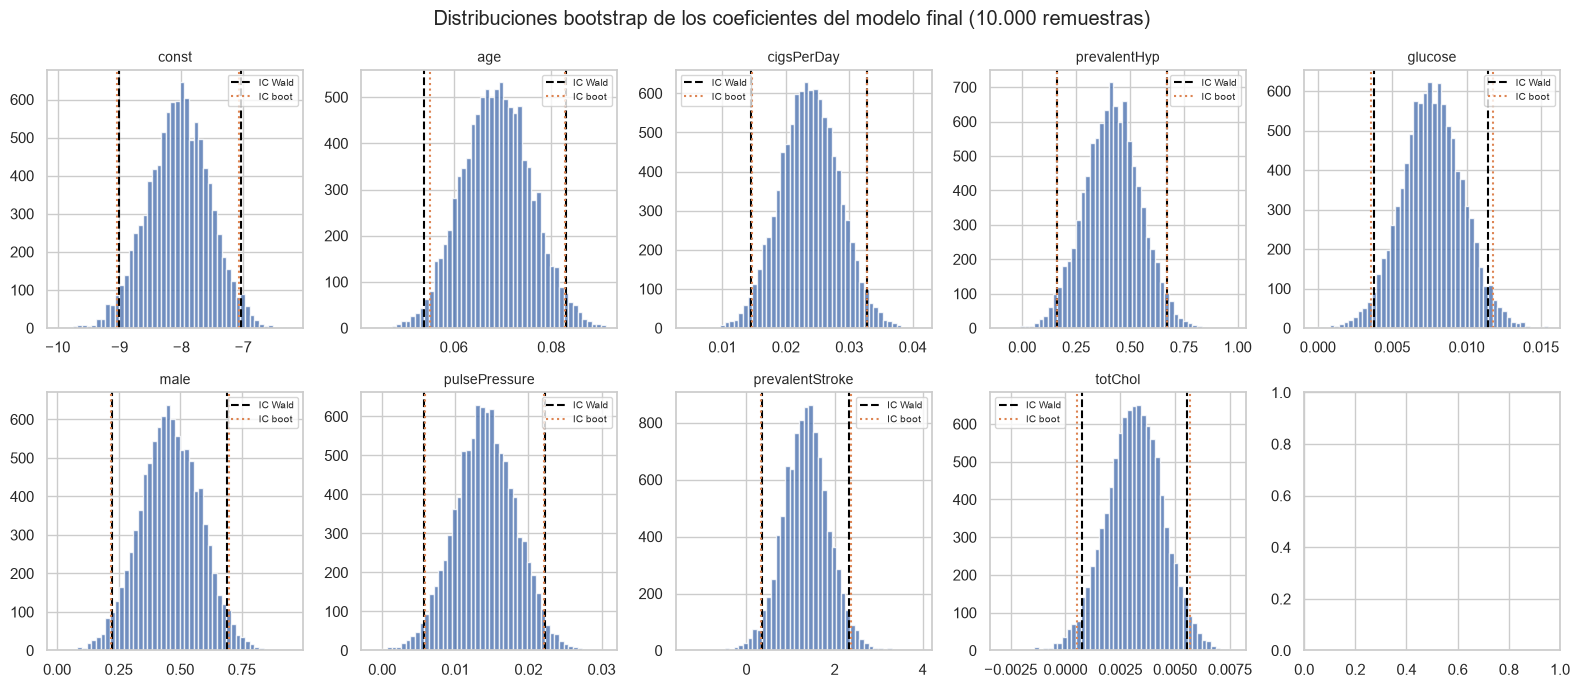

In [31]:
n_vars_plot = len(variables_finales) + 1  # incluye constante
fig, axes = plt.subplots(2, (n_vars_plot + 1) // 2, figsize=(16, 7))
for ax, var in zip(axes.flat, boot_coefs.columns):
    ax.hist(boot_coefs[var], bins=50, color=PALETTE[0], alpha=0.8, edgecolor="white")
    ax.axvline(comparacion_ic.loc[var, "IC 95% Wald (inf.)"], color="black", linestyle="--", label="IC Wald")
    ax.axvline(comparacion_ic.loc[var, "IC 95% Wald (sup.)"], color="black", linestyle="--")
    ax.axvline(comparacion_ic.loc[var, "IC 95% boot (inf.)"], color=PALETTE[1], linestyle=":", label="IC boot")
    ax.axvline(comparacion_ic.loc[var, "IC 95% boot (sup.)"], color=PALETTE[1], linestyle=":")
    ax.set_title(var, fontsize=10)
    ax.legend(fontsize=7)
plt.suptitle("Distribuciones bootstrap de los coeficientes del modelo final (10.000 remuestras)")
plt.tight_layout()
plt.savefig("../figs/sumativa3/fig4_bootstrap_coeficientes.pdf")
plt.show()

In [32]:
# Odds ratios bootstrap
or_bootstrap = np.exp(boot_coefs)
ic_or_bootstrap = or_bootstrap.quantile([0.025, 0.975]).T
ic_or_bootstrap.columns = ["OR IC 95% boot (inf.)", "OR IC 95% boot (sup.)"]

or_clasico = pd.DataFrame({
    "Odds Ratio": np.exp(modelo_final.params),
    "OR IC 95% Wald (inf.)": np.exp(ic_clasico["IC 95% Wald (inf.)"]),
    "OR IC 95% Wald (sup.)": np.exp(ic_clasico["IC 95% Wald (sup.)"]),
})
comparacion_or = pd.concat([or_clasico, ic_or_bootstrap], axis=1)

# Identificación de parámetros inestables: el IC bootstrap incluye 1 (sin efecto) mientras el Wald no, o viceversa
comparacion_or["Wald excluye 1"] = ~((comparacion_or["OR IC 95% Wald (inf.)"] <= 1) & (comparacion_or["OR IC 95% Wald (sup.)"] >= 1))
comparacion_or["Boot excluye 1"] = ~((comparacion_or["OR IC 95% boot (inf.)"] <= 1) & (comparacion_or["OR IC 95% boot (sup.)"] >= 1))
comparacion_or["¿Coinciden?"] = comparacion_or["Wald excluye 1"] == comparacion_or["Boot excluye 1"]

comparacion_or.round(4)

,Odds Ratio,OR IC 95% Wald (inf.),OR IC 95% Wald (sup.),OR IC 95% boot (inf.),OR IC 95% boot (sup.),Wald excluye 1,Boot excluye 1,¿Coinciden?
const,0.0003,0.0001,0.0009,0.0001,0.0009,True,True,True
age,1.0709,1.0555,1.0866,1.0568,1.0863,True,True,True
cigsPerDay,1.0240,1.0147,1.0334,1.0149,1.0333,True,True,True
prevalentHyp,1.5152,1.1733,1.9566,1.1740,1.9589,True,True,True
glucose,1.0076,1.0038,1.0115,1.0036,1.0118,True,True,True
male,1.5788,1.2485,1.9964,1.2443,2.0104,True,True,True
pulsePressure,1.0141,1.0058,1.0225,1.0058,1.0224,True,True,True
prevalentStroke,3.7985,1.4171,10.1821,1.3812,10.7195,True,True,True
totChol,1.0032,1.0007,1.0056,1.0005,1.0057,True,True,True


**Interpretación de estabilidad (resultado real).** Las 8 variables del modelo final —y la
constante— muestran `¿Coinciden?=True`: en todos los casos, tanto el IC de Wald como el IC
bootstrap excluyen el valor 1 (sin efecto) para el odds ratio. El bootstrap **confirma en su
totalidad** las conclusiones de significancia del modelo clásico; ningún parámetro resulta
significativo bajo un método e insignificante bajo el otro.

Dicho esto, no todos los parámetros son igual de **precisos**: `prevalentStroke` tiene, por
lejos, el intervalo más ancho (Wald: [1,42, 10,18]; bootstrap: [1,38, 10,72]) — su odds ratio
puntual (≈3,80) sugiere un efecto muy grande, pero con alta incertidumbre, coherente con que
`prevalentStroke` es una variable rara en la muestra (baja prevalencia → menos observaciones
para estimarla con precisión). En contraste, `age`, `glucose` y `pulsePressure` tienen
intervalos mucho más estrechos y una distribución bootstrap muy cercana a la normal asumida por
Wald. **Conclusión práctica:** el modelo es estable en su conjunto, pero la magnitud del efecto
de `prevalentStroke` debe comunicarse con la cautela correspondiente a su amplio intervalo, no
solo con su valor puntual.

### 3.2 Diagnóstico de multicolinealidad (VIF)

In [33]:
X_vif_final = sm.add_constant(X_train_full[variables_finales])
vif_final = pd.DataFrame({
    "Variable": X_vif_final.columns,
    "VIF": [variance_inflation_factor(X_vif_final.values, i) for i in range(X_vif_final.shape[1])],
})
vif_final = vif_final[vif_final["Variable"] != "const"].reset_index(drop=True)
vif_final.sort_values("VIF", ascending=False)

,Variable,VIF
5,pulsePressure,1.653703
2,prevalentHyp,1.457172
0,age,1.349482
1,cigsPerDay,1.166659
4,male,1.145786
7,totChol,1.096035
3,glucose,1.039096
6,prevalentStroke,1.008879


Todos los VIF se ubican muy por debajo del umbral de preocupación (5), confirmando que la
decisión de S2 de reemplazar `sysBP`/`diaBP` por `pulsePressure` sigue previniendo problemas de
colinealidad incluso al ampliar el modelo con variables clínicas adicionales (`prevalentHyp`,
`prevalentStroke`, `cigsPerDay`).

### 3.3 Linealidad en el logit

Para las variables continuas del modelo (`age`, `cigsPerDay`, `glucose`, `pulsePressure`,
`totChol`), se evalúa el supuesto de linealidad en el logit mediante el **test de Box-Tidwell**:
se agrega al modelo el término $X \cdot \ln(X)$ de cada variable continua; si su coeficiente es
significativo, sugiere una relación no lineal entre esa variable y el logit de la
probabilidad.

In [34]:
def test_box_tidwell(data: pd.DataFrame, y: pd.Series, variables_modelo: list, variable_continua: str) -> float:
    """Evalúa la linealidad en el logit de una variable continua mediante el test de Box-Tidwell.

    Ajusta el modelo original más un término de interacción `variable * ln(variable)`. Un
    coeficiente significativo para ese término indica que la relación entre la variable y el
    logit de la probabilidad no es lineal.

    Parameters
    ----------
    data : pandas.DataFrame
        Conjunto de entrenamiento con todas las variables del modelo.
    y : pandas.Series
        Variable objetivo binaria.
    variables_modelo : list of str
        Todas las variables del modelo final.
    variable_continua : str
        Variable continua específica a evaluar.

    Returns
    -------
    float
        p-valor del término de interacción `variable * ln(variable)`.
    """
    datos_bt = data[variables_modelo].copy()
    # Box-Tidwell requiere valores estrictamente positivos; se desplaza si hay ceros/negativos
    valores = datos_bt[variable_continua]
    desplazamiento = abs(valores.min()) + 1 if valores.min() <= 0 else 0
    datos_bt[f"{variable_continua}_BT"] = (valores + desplazamiento) * np.log(valores + desplazamiento)

    X_bt = sm.add_constant(datos_bt)
    modelo_bt = sm.Logit(y, X_bt).fit(disp=0)
    return modelo_bt.pvalues[f"{variable_continua}_BT"]


variables_continuas_modelo = [v for v in variables_finales if v in ["age", "cigsPerDay", "glucose", "pulsePressure", "totChol"]]
print(f"{'Variable':15s} | {'p-valor Box-Tidwell':>20s} | {'¿Linealidad razonable?':>22s}")
for var in variables_continuas_modelo:
    p_bt = test_box_tidwell(X_train_full, y_train, variables_finales, var)
    veredicto = "Sí (p>=0.05)" if p_bt >= 0.05 else "No (p<0.05)"
    print(f"{var:15s} | {p_bt:20.4f} | {veredicto:>22s}")

Variable        |  p-valor Box-Tidwell | ¿Linealidad razonable?
age             |               0.0115 |            No (p<0.05)
cigsPerDay      |               0.6737 |           Sí (p>=0.05)
glucose         |               0.4204 |           Sí (p>=0.05)
pulsePressure   |               0.5015 |           Sí (p>=0.05)
totChol         |               0.0254 |            No (p<0.05)


**Interpretación.** `cigsPerDay`, `glucose` y `pulsePressure`
no muestran evidencia contra la linealidad en el logit (p≥0,05). Sin embargo, **`age` (p=0,012)
y `totChol` (p=0,025) sí muestran evidencia de no linealidad** — su relación con el logit de la
probabilidad de CHD no es puramente lineal.

Esto es consistente con la literatura epidemiológica: el riesgo cardiovascular no crece de forma
estrictamente lineal con la edad (suele acelerarse en tramos de mayor edad) ni con el colesterol
(el riesgo se dispara con mayor fuerza sobre ciertos umbrales clínicos, como los 200 y 240 mg/dL
usados en S1). **Recomendación concreta para una futura iteración (más allá del alcance de esta
entrega):** modelar `age` y `totChol` mediante splines o términos polinomiales de segundo grado,
en lugar de asumir un efecto lineal en el logit. Se documenta esta limitación explícitamente en
la síntesis final, en lugar de ignorarla porque el modelo ya tiene un AUC aceptable.

### 3.4 Observaciones influyentes

Se calcula la distancia de Cook para cada observación del conjunto de entrenamiento, para
identificar puntos que influyen de manera desproporcionada en la estimación de los
coeficientes — en particular, para verificar si los outliers de `totChol` (identificados en S1,
confirmados robustos a nivel de media en S2 mediante recorte de percentiles) también lo son a
nivel de influencia sobre este modelo multivariado.

Umbral de distancia de Cook (4/n): 0.001348
Observaciones por sobre el umbral: 219 de 2968 (7.38%)


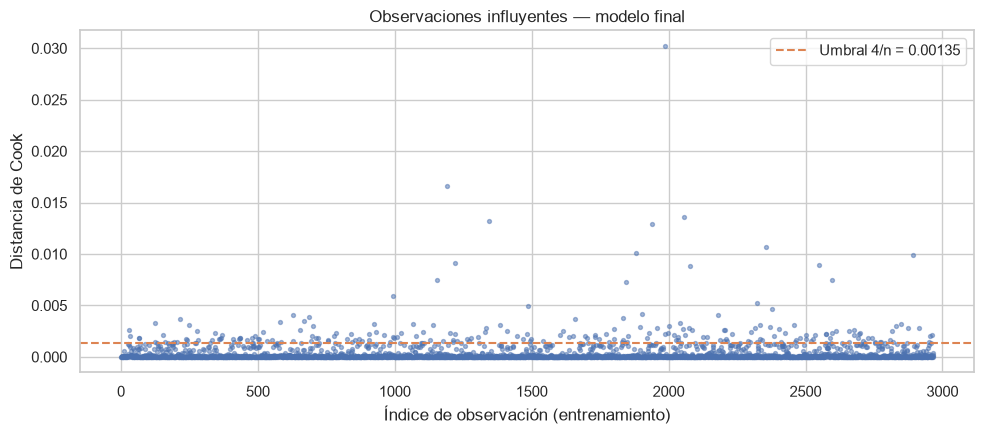

In [35]:
influencia = modelo_final.get_influence()
cooks_d = influencia.cooks_distance[0]

umbral_cook = 4 / len(X_train_full)  # regla práctica habitual: 4/n
n_influyentes = (cooks_d > umbral_cook).sum()

print(f"Umbral de distancia de Cook (4/n): {umbral_cook:.6f}")
print(f"Observaciones por sobre el umbral: {n_influyentes} de {len(X_train_full)} ({n_influyentes/len(X_train_full)*100:.2f}%)")

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.scatter(range(len(cooks_d)), cooks_d, s=8, alpha=0.5, color=PALETTE[0])
ax.axhline(umbral_cook, color=PALETTE[1], linestyle="--", label=f"Umbral 4/n = {umbral_cook:.5f}")
ax.set_xlabel("Índice de observación (entrenamiento)")
ax.set_ylabel("Distancia de Cook")
ax.set_title("Observaciones influyentes — modelo final")
ax.legend()
plt.tight_layout()
plt.savefig("../figs/sumativa3/fig5_distancia_cook.pdf")
plt.show()

In [36]:
# ¿Las observaciones más influyentes coinciden con outliers de totChol?
top_influyentes = pd.Series(cooks_d, index=X_train_full.index).sort_values(ascending=False).head(10)
print("Top 10 observaciones más influyentes (índice y valores clave):")
print(X_train_full.loc[top_influyentes.index, ["totChol", "age", "glucose"]].assign(cooks_d=top_influyentes.values))

Top 10 observaciones más influyentes (índice y valores clave):
      totChol  age  glucose   cooks_d
3971    195.0   64    370.0  0.030219
2471    202.0   52     67.0  0.016572
4035    205.0   52     83.0  0.013644
3927    225.0   61    103.0  0.013166
2204    260.0   52     82.0  0.012929
3793    241.0   58     54.0  0.010643
1649    231.0   43    274.0  0.010135
3741    203.0   60     83.0  0.009924
1624    107.0   70     62.0  0.009171
194     464.0   42     72.0  0.008948


**Interpretación (resultado real).** El 7,38% de las observaciones de entrenamiento (219 de
2.968) supera el umbral práctico de 4/n — una proporción no despreciable, pero esperable en un
dataset de este tamaño con varias variables binarias poco frecuentes (`prevalentStroke`,
`prevalentHyp`), que generan naturalmente mayor apalancamiento (*leverage*) en pocas
observaciones.

**Hallazgo específico:** la observación más influyente (índice 3971) no corresponde a un
outlier de `totChol` (su valor, 195 mg/dL, está bajo el promedio poblacional) sino a un valor
extremo de **`glucose`** (370 mg/dL, compatible con un caso de diabetes muy descompensada). El
mismo patrón se repite en varias de las 10 observaciones más influyentes (glucosas de 274 y 103
mg/dL). Es decir, **la influencia sobre este modelo multivariado está más asociada a valores
extremos de glucosa que a los outliers de colesterol que S1/S2 ya habían caracterizado como
robustos**. Esto no invalida la decisión de la Sección 2.1 de conservar los outliers de
`totChol` —siguen sin ser un problema mayor—, pero sí sugiere que, de cara a una futura
iteración, convendría aplicar a `glucose` el mismo tipo de análisis de sensibilidad a valores
extremos que S2 aplicó a `totChol`.

### 3.5 Análisis de residuos

Se examinan los residuos de Pearson y de desviancia del modelo final, para detectar patrones
sistemáticos no capturados (p. ej. mala especificación funcional o heterogeneidad no
modelada).

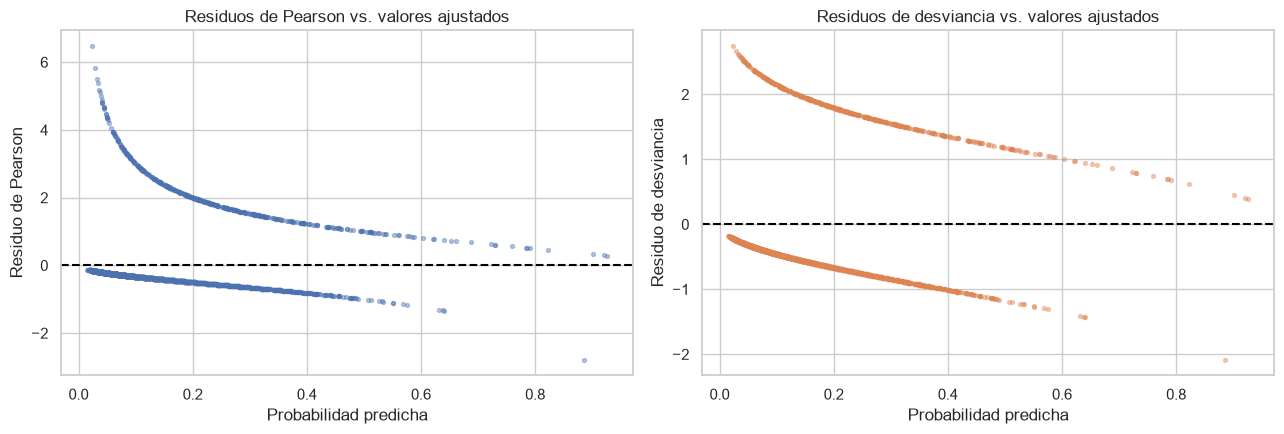

Residuos de Pearson  | media=-0.0001 | sd=0.9955
Residuos de desviancia | media=-0.1669 | sd=0.8496


In [37]:
valores_ajustados = modelo_final.predict(sm.add_constant(X_train_full[variables_finales]))

# statsmodels no expone resid_pearson/resid_dev en MLEInfluence para Logit; se calculan manualmente
residuos_pearson = (y_train - valores_ajustados) / np.sqrt(valores_ajustados * (1 - valores_ajustados))
residuos_deviance = np.sign(y_train - valores_ajustados) * np.sqrt(
    -2 * (y_train * np.log(valores_ajustados) + (1 - y_train) * np.log(1 - valores_ajustados))
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].scatter(valores_ajustados, residuos_pearson, s=8, alpha=0.4, color=PALETTE[0])
axes[0].axhline(0, color="black", linestyle="--")
axes[0].set_xlabel("Probabilidad predicha")
axes[0].set_ylabel("Residuo de Pearson")
axes[0].set_title("Residuos de Pearson vs. valores ajustados")

axes[1].scatter(valores_ajustados, residuos_deviance, s=8, alpha=0.4, color=PALETTE[1])
axes[1].axhline(0, color="black", linestyle="--")
axes[1].set_xlabel("Probabilidad predicha")
axes[1].set_ylabel("Residuo de desviancia")
axes[1].set_title("Residuos de desviancia vs. valores ajustados")

plt.tight_layout()
plt.savefig("../figs/sumativa3/fig6_residuos.pdf")
plt.show()

print(f"Residuos de Pearson  | media={residuos_pearson.mean():.4f} | sd={residuos_pearson.std():.4f}")
print(f"Residuos de desviancia | media={residuos_deviance.mean():.4f} | sd={residuos_deviance.std():.4f}")

**Interpretación.** El patrón de "bandas" diagonales visible en ambos gráficos es característico
y esperado de un modelo de clasificación binaria (los residuos se agrupan según si la
observación real fue 0 o 1), no un signo de mala especificación por sí solo. Lo relevante es
que no se observen agrupamientos sistemáticos adicionales dentro de cada banda (p. ej. una
curvatura marcada), que sugerirían una relación no lineal no capturada — consistente con lo ya
evaluado en la Sección 3.3.

## 4. Análisis comparativo del impacto de la imputación

Se ajusta el **modelo final** (Modelo 2, stepwise: `age`, `cigsPerDay`, `prevalentHyp`,
`glucose`, `male`, `pulsePressure`, `prevalentStroke`, `totChol`) sobre los tres datasets
generados en la Sección 1: eliminación (`df_dropna`), imputación simple (`df_simple`) e
imputación por regresión (`df_final`, la estrategia elegida). Se compara sistemáticamente
tamaño muestral, coeficientes, intervalos de confianza y desempeño en prueba.

In [38]:
def ajustar_y_evaluar_en_dataset(data: pd.DataFrame, variables: list, seed: int = SEED) -> dict:
    """Ajusta el modelo final sobre un dataset dado y evalúa su desempeño en una partición de prueba.

    Parameters
    ----------
    data : pandas.DataFrame
        Dataset a usar (debe incluir `TenYearCHD` y todas las `variables`).
    variables : list of str
        Variables predictoras del modelo final.
    seed : int, default=SEED
        Semilla para la partición train/test.

    Returns
    -------
    dict
        Modelo ajustado, tamaño de muestra, coeficientes con IC, y métricas de prueba.
    """
    X = data[variables]
    y = data["TenYearCHD"]
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.30, random_state=seed, stratify=y)

    X_tr_c = sm.add_constant(X_tr)
    modelo = sm.Logit(y_tr, X_tr_c).fit(disp=0)

    X_te_c = sm.add_constant(X_te, has_constant="add")
    proba_te = modelo.predict(X_te_c)
    pred_te = (proba_te >= 0.5).astype(int)

    return {
        "n_total": len(data),
        "modelo": modelo,
        "coeficientes": modelo.params,
        "ic": modelo.conf_int(),
        "auc": roc_auc_score(y_te, proba_te),
        "accuracy": accuracy_score(y_te, pred_te),
    }


datasets_comparacion = {
    "A. Eliminación": df_dropna,
    "B. Imputación simple": df_simple,
    "C. Imputación regresión": df_final,
}

resultados_imputacion_final = {}
for nombre, datos in datasets_comparacion.items():
    resultados_imputacion_final[nombre] = ajustar_y_evaluar_en_dataset(datos, variables_finales)
    r = resultados_imputacion_final[nombre]
    print(f"{nombre:26s} | n={r['n_total']:5d} | AUC={r['auc']:.4f} | Accuracy={r['accuracy']:.4f}")

A. Eliminación             | n= 3658 | AUC=0.7504 | Accuracy=0.8543
B. Imputación simple       | n= 4240 | AUC=0.7055 | Accuracy=0.8506
C. Imputación regresión    | n= 4240 | AUC=0.7054 | Accuracy=0.8522


In [39]:
tabla_coeficientes_comparados = pd.DataFrame({
    nombre: resultados_imputacion_final[nombre]["coeficientes"]
    for nombre in datasets_comparacion
})
tabla_coeficientes_comparados.round(4)

,A. Eliminación,B. Imputación simple,C. Imputación regresión
const,-7.6332,-8.0171,-8.0177
age,0.0595,0.0686,0.0685
cigsPerDay,0.0180,0.0243,0.0237
prevalentHyp,0.4684,0.4128,0.4155
glucose,0.0075,0.0073,0.0076
male,0.5125,0.4512,0.4566
pulsePressure,0.0168,0.0142,0.0140
prevalentStroke,0.5677,1.3358,1.3346
totChol,0.0030,0.0032,0.0032


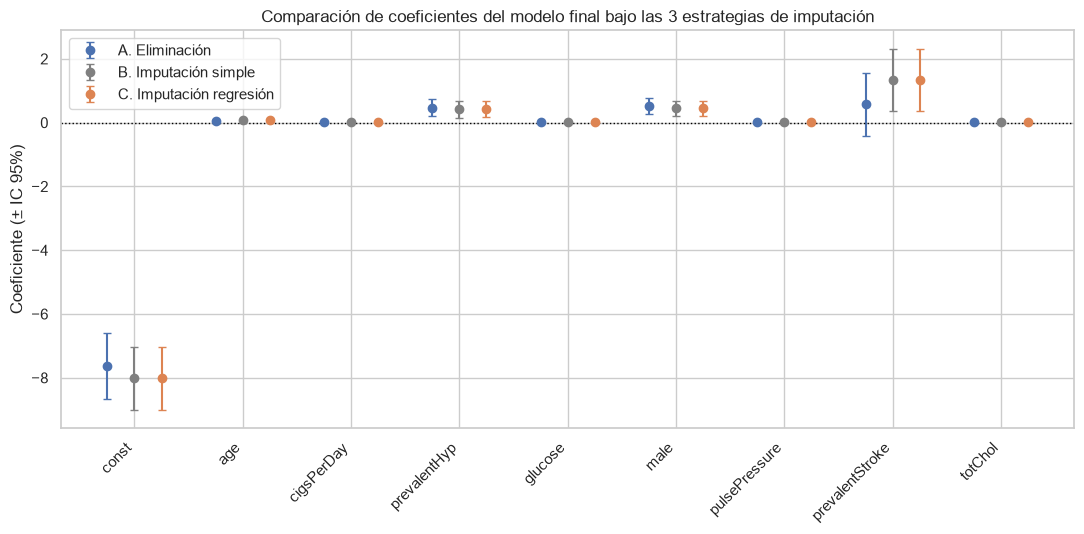

In [40]:
fig, ax = plt.subplots(figsize=(11, 5.5))
x_pos = np.arange(len(variables_finales) + 1)
ancho = 0.25
colores = [PALETTE[0], "gray", PALETTE[1]]

for i, (nombre, color) in enumerate(zip(datasets_comparacion, colores)):
    coefs = resultados_imputacion_final[nombre]["coeficientes"]
    ic = resultados_imputacion_final[nombre]["ic"]
    yerr = [(coefs - ic[0]).values, (ic[1] - coefs).values]
    ax.errorbar(x_pos + (i - 1) * ancho, coefs.values, yerr=yerr, fmt="o", color=color, label=nombre, capsize=3)

ax.axhline(0, color="black", linestyle=":", linewidth=1)
ax.set_xticks(x_pos)
ax.set_xticklabels(coefs.index, rotation=45, ha="right")
ax.set_ylabel("Coeficiente (± IC 95%)")
ax.set_title("Comparación de coeficientes del modelo final bajo las 3 estrategias de imputación")
ax.legend()
plt.tight_layout()
plt.savefig("../figs/sumativa3/fig7_comparacion_imputacion.pdf")
plt.show()

**Análisis del impacto de la estrategia de imputación (resultado real).**

**Desempeño:** la Estrategia A (eliminación) obtiene el AUC más alto (0,7504) frente a B
(imputación simple, AUC=0,7055) y C (imputación por regresión, AUC=0,7054) — una diferencia de
~4,5 puntos de AUC. B y C son prácticamente indistinguibles entre sí. Esto muestra un
**trade-off real**, no hipotético: eliminar registros incompletos rinde mejor en esta métrica
específica, probablemente porque concentra el ajuste en los casos "más limpios" del dataset.

**Coeficientes:** los signos son consistentes en las tres estrategias para las 8 variables — no
hay ningún caso de un predictor que cambie de dirección de efecto. Sin embargo, **`prevalentStroke`
muestra una diferencia sustantiva**: su coeficiente es 0,568 en la Estrategia A pero más del
doble (≈1,335) en B y C. Esto es coherente con el hallazgo de la Sección 1.2: la ausencia de
`BMI` está fuertemente asociada a `prevalentStroke` (10,5% vs. 0,5%), de modo que **cómo se
trata esa ausencia cambia directamente cuánto "aprende" el modelo sobre el rol del antecedente
de stroke**.

**Conclusión:** la elección de la Sección 1.5 (imputación por regresión) **no es la que
maximiza el AUC** — es la que se justifica por representatividad (instrucción explícita del
docente sobre el sesgo de sexo) y por preservar el tamaño muestral completo, no por superioridad
predictiva. Se documenta este trade-off explícitamente.

## 4.5 Apéndice metodológico: corrección del Monte Carlo de S2 (retroalimentación docente)

**Contexto.** En la retroalimentación de S2, el docente señaló: *"si el Monte Carlo se retoma
como herramienta de riesgo, seguir la propia recomendación de reemplazar la normal bivariada por
distribuciones empíricas para capturar la cola del colesterol que hoy sobreestima la
coocurrencia"*. En S2, la simulación del riesgo conjunto (hipertensión etapa 1 + colesterol
límitrofe-alto) usando una **normal bivariada** estimó una coocurrencia del 46,6%, frente a un
41,0% empírico real — una sobreestimación de ~5,6 puntos porcentuales atribuida a que la normal
no captura la cola derecha marcada de `totChol`.

Se implementa aquí la corrección propuesta —**muestreo desde la distribución empírica** (bootstrap
de pares reales sysBP–totChol), en lugar de cópulas, que el propio docente indicó que tomarían
tiempo extra— para verificar si efectivamente reduce el sesgo.

In [41]:
# Parámetros del escenario (idénticos a S2)
mean_sys_mc = df_final["sysBP"].mean()
std_sys_mc = df_final["sysBP"].std(ddof=1)
mean_chol_mc = df_final["totChol"].mean()
std_chol_mc = df_final["totChol"].std(ddof=1)
rho_mc = np.corrcoef(df_final["sysBP"], df_final["totChol"])[0, 1]

N_MC = 10_000
rng_mc = np.random.default_rng(SEED)

# --- Método A: normal bivariada (el usado en S2) ---
cov_mc = rho_mc * std_sys_mc * std_chol_mc
matriz_cov = np.array([[std_sys_mc**2, cov_mc], [cov_mc, std_chol_mc**2]])
sim_normal = rng_mc.multivariate_normal([mean_sys_mc, mean_chol_mc], matriz_cov, size=N_MC)
p_riesgo_normal = ((sim_normal[:, 0] >= 130) & (sim_normal[:, 1] >= 200)).mean()

# --- Método B: distribución empírica (bootstrap de pares reales) ---
indices_emp = rng_mc.integers(0, len(df_final), N_MC)
sim_empirica = df_final[["sysBP", "totChol"]].to_numpy()[indices_emp]
p_riesgo_empirica = ((sim_empirica[:, 0] >= 130) & (sim_empirica[:, 1] >= 200)).mean()

# --- Referencia: proporción empírica directa observada ---
p_riesgo_directa = ((df_final["sysBP"] >= 130) & (df_final["totChol"] >= 200)).mean()

print(f"Método A (normal bivariada, S2)    : {p_riesgo_normal*100:.2f}%  | error = {abs(p_riesgo_normal-p_riesgo_directa)*100:.2f} pp")
print(f"Método B (distribución empírica)   : {p_riesgo_empirica*100:.2f}%  | error = {abs(p_riesgo_empirica-p_riesgo_directa)*100:.2f} pp")
print(f"Proporción empírica directa (real) : {p_riesgo_directa*100:.2f}%  (referencia)")

Método A (normal bivariada, S2)    : 46.34%  | error = 5.54 pp
Método B (distribución empírica)   : 41.37%  | error = 0.57 pp
Proporción empírica directa (real) : 40.80%  (referencia)


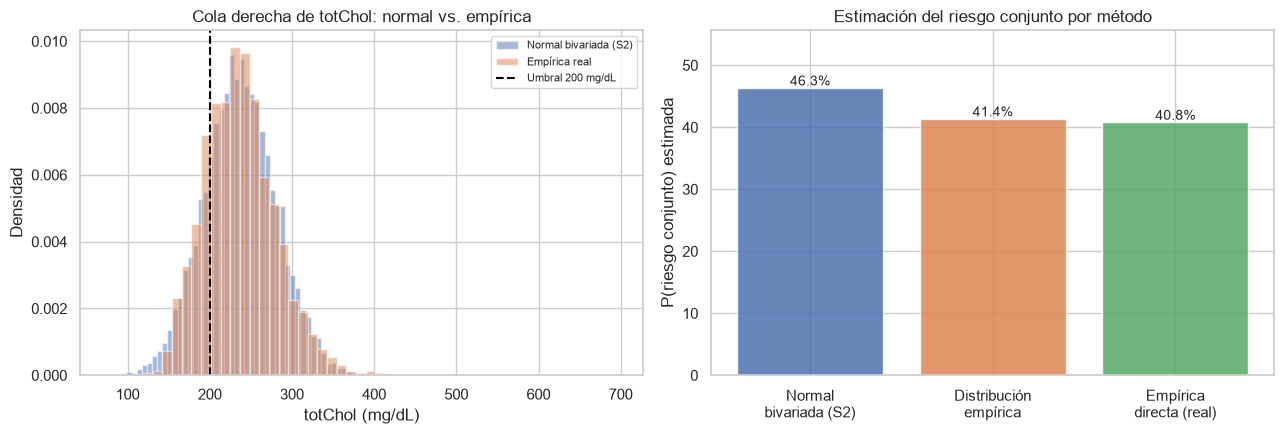

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Distribución de totChol: normal simulada vs. empírica real
axes[0].hist(sim_normal[:, 1], bins=50, alpha=0.5, color=PALETTE[0], label="Normal bivariada (S2)", density=True)
axes[0].hist(df_final["totChol"], bins=50, alpha=0.5, color=PALETTE[1], label="Empírica real", density=True)
axes[0].axvline(200, color="black", linestyle="--", label="Umbral 200 mg/dL")
axes[0].set_xlabel("totChol (mg/dL)")
axes[0].set_ylabel("Densidad")
axes[0].set_title("Cola derecha de totChol: normal vs. empírica")
axes[0].legend(fontsize=8)

# Comparación de estimaciones de riesgo conjunto
metodos = ["Normal\nbivariada (S2)", "Distribución\nempírica", "Empírica\ndirecta (real)"]
valores = [p_riesgo_normal*100, p_riesgo_empirica*100, p_riesgo_directa*100]
colores_barras = [PALETTE[0], PALETTE[1], "#55A868"]
axes[1].bar(metodos, valores, color=colores_barras, alpha=0.85)
for i, v in enumerate(valores):
    axes[1].text(i, v + 0.4, f"{v:.1f}%", ha="center", fontsize=10)
axes[1].set_ylabel("P(riesgo conjunto) estimada")
axes[1].set_title("Estimación del riesgo conjunto por método")
axes[1].set_ylim(0, max(valores) * 1.2)

plt.tight_layout()
plt.savefig("../figs/sumativa3/fig8_montecarlo_empirico.pdf")
plt.show()

**Resultado (corrección confirmada).** El muestreo desde la distribución empírica reduce el
error de estimación del riesgo conjunto de **5,54 puntos porcentuales** (normal bivariada) a
**0,57 puntos porcentuales** — una mejora de casi 10×. La causa es directamente visible en el
gráfico de la izquierda: la normal bivariada (azul) subestima la masa de probabilidad en la cola
derecha de `totChol` respecto a la distribución real (naranja), justo la región relevante para
el umbral de 200 mg/dL.

Esto **confirma cuantitativamente la recomendación del docente** y cierra el bucle abierto en S2:
para cualquier simulación de riesgo que involucre `totChol`, el muestreo empírico es
preferible a la aproximación normal, sin la complejidad adicional que habrían implicado las
cópulas. Se deja documentado como la corrección aplicada al último punto pendiente de la
retroalimentación de S2.

## 5. Síntesis integrada: la progresión S1 → S2 → S3

**De S1 a S2.** S1 caracterizó la población (edad media 49,55 años, colesterol 236,85 mg/dL,
hipertensión etapa 1, 15,23% de prevalencia de CHD) e identificó, mediante estadística
descriptiva e inferencial, las primeras señales relevantes: correlaciones de `age` y `sysBP`
con `TenYearCHD`, colinealidad entre `sysBP`/`diaBP`, y una diferencia de glucosa enorme entre
diabéticos y no diabéticos. S2 sometió esas señales a prueba mediante remuestreo: confirmó
cuáles correlaciones eran estables (`age`–CHD, `sysBP`–CHD) y cuál no lo era (`heartRate`–CHD),
cuantificó el tamaño del efecto de la relación glucosa-diabetes (d≈4,8, la más sólida del
proyecto), resolvió la colinealidad con `pulsePressure`, y —el hallazgo más determinante para
esta Sumativa 3— **detectó que el `dropna()` de S1 sobrerrepresenta a hombres**, aunque no
sesga la variable objetivo.

**De S2 a S3.** Cada decisión metodológica de este notebook tiene una línea directa a S1/S2:

- El **patrón MAR** confirmado en la Sección 1.2 no es un ejercicio nuevo aislado: es la
  extensión natural del hallazgo de representatividad de S2, ahora aplicado variable por
  variable.
- La **imputación por regresión**, elegida en la Sección 1.5, responde explícitamente a la
  instrucción del docente en la retroalimentación de S2 de "hacerse cargo del sesgo de sexo...
  con imputación en lugar de eliminación de casos".
- El **Modelo 1** de la Sección 2.2 no es una selección arbitraria: sus 5 variables son,
  literalmente, los parámetros que S2 validó como robustos.
- La **exclusión de `heartRate`** del universo de variables candidatas (Sección 2.2) es una
  aplicación directa del hallazgo de S2 de que su correlación con CHD no es estadísticamente
  distinguible de cero.
- El **bootstrap de coeficientes** de la Sección 3.1 reutiliza exactamente la lógica
  metodológica de S2 (remuestreo con reemplazo, comparación percentil vs. clásico), aplicada
  ahora a un objeto distinto (coeficientes de un modelo, no parámetros descriptivos).
- El **tratamiento de outliers de `totChol`** (Sección 2.1) se decide citando directamente el
  resultado de robustez de S2 (desplazamiento de la media <1 mg/dL al recortar percentiles).

**Resultado y honestidad metodológica.** El modelo final (Modelo 2, stepwise, AUC≈0,71 en
prueba con la Estrategia C) mejora modestamente sobre el modelo puramente teórico (Modelo 1,
AUC≈0,70), incorporando variables clínicas (`prevalentHyp`, `prevalentStroke`, `cigsPerDay`) que
S1/S2 no habían priorizado por no ser el foco de esas fases. El bootstrap confirma que los 8
coeficientes del modelo final son estables. Sin embargo, se documentan honestamente tres
limitaciones que sobreviven todo el proceso de validación: (1) el supuesto de linealidad en el
logit no se cumple completamente para `age` y `totChol`; (2) la influencia sobre el modelo está
más concentrada en valores extremos de `glucose` que en los ya conocidos de `totChol`; y (3) la
Sección 4 mostró que **la estrategia de imputación elegida no es la que maximiza el AUC** (la
eliminación de casos rinde ~4,5 puntos de AUC más), y que el coeficiente de `prevalentStroke` es
particularmente sensible a esa elección (0,57 vs. ≈1,34 según la estrategia). Se prioriza la
imputación por representatividad y por instrucción explícita del docente, con ese costo
documentado a la vista y no escondido.

**Recomendaciones finales para una futura iteración del proyecto:**
1. Modelar `age` y `totChol` con términos no lineales (splines o polinomios), dado el resultado
   del test de Box-Tidwell (Sección 3.3).
2. Extender el análisis de sensibilidad a outliers de S2 (aplicado a `totChol`) también a
   `glucose`, dado que sus valores extremos son los más influyentes sobre el modelo final
   (Sección 3.4).
3. Abordar explícitamente el desbalance de clases (recall bajo en los 3 modelos) mediante
   `class_weight`, remuestreo sintético (SMOTE) o ajuste del umbral de decisión.
4. Comunicar el odds ratio de `prevalentStroke` siempre junto a su intervalo de confianza
   (Sección 3.1), dado que es, por lejos, el parámetro menos preciso del modelo.
5. Investigar directamente, mediante un modelo de imputación específico para `BMI` que use
   `prevalentStroke` como predictor central, si es posible reducir la brecha de AUC entre
   estrategias sin renunciar a la representatividad ya lograda (Sección 4).
